# Генерация изображений: CIFAR-10

In [1]:
%pip install torch torchvision matplotlib numpy scikit-learn imbalanced-learn ipywidgets

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
import math

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms

from sklearn.mixture import GaussianMixture
from imblearn.over_sampling import SMOTE
from tqdm.notebook import tqdm, trange

plt.rcParams['figure.dpi'] = 120

In [3]:
device = torch.device('mps')
torch.manual_seed(123)
np.random.seed(123)

transform = transforms.ToTensor()
full_train = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
full_test = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

names = ['airplane', 'automobile', 'ship']
target_classes = [0, 1, 8]

train_imgs, train_labs = [], []
for i in range(len(full_train)):
    img, label = full_train[i]
    if label in target_classes:
        train_imgs.append(img)
        train_labs.append(target_classes.index(label))

test_imgs, test_labs = [], []
for i in range(len(full_test)):
    img, label = full_test[i]
    if label in target_classes:
        test_imgs.append(img)
        test_labs.append(target_classes.index(label))

train_ds = TensorDataset(torch.stack(train_imgs), torch.tensor(train_labs))
test_ds = TensorDataset(torch.stack(test_imgs), torch.tensor(test_labs))

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True)
test_loader = DataLoader(test_ds, batch_size=128)

print(f'Train {len(train_ds)}, Test {len(test_ds)}')

Train 15000, Test 3000


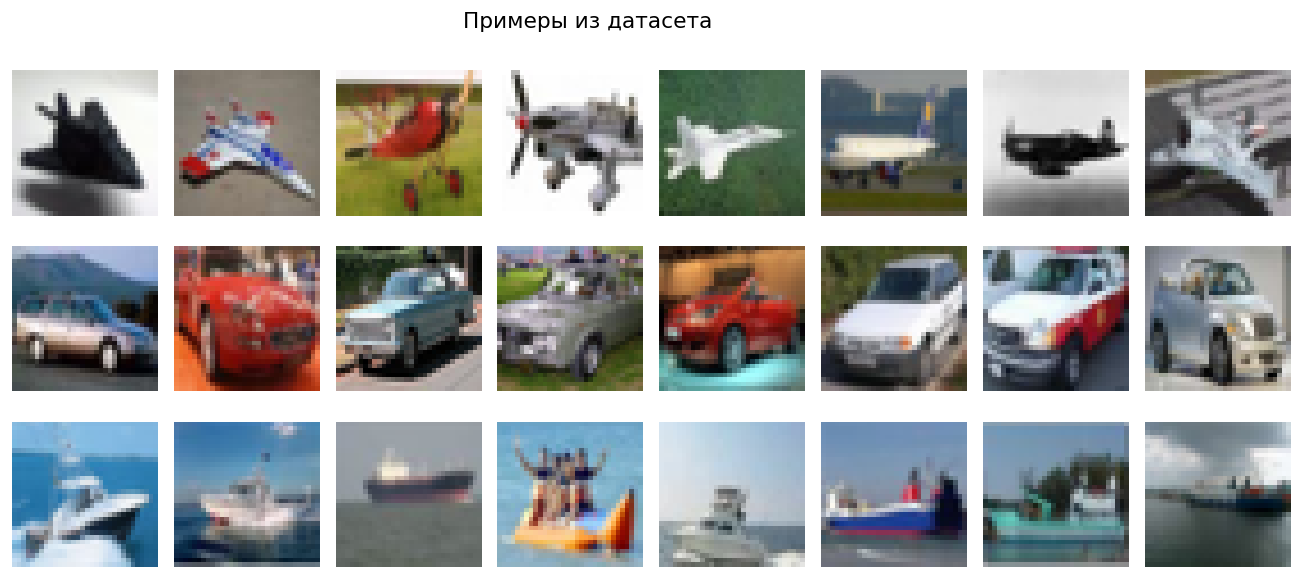

In [4]:
all_imgs, all_labs = train_ds.tensors

fig, axes = plt.subplots(3, 8, figsize=(12, 5))
fig.suptitle('Примеры из датасета', fontsize=13)
for c in range(3):
    cls_imgs = all_imgs[all_labs == c][:8]
    for j in range(8):
        axes[c][j].imshow(cls_imgs[j].permute(1, 2, 0).numpy())
        axes[c][j].axis('off')
    axes[c][0].set_ylabel(names[c], fontsize=11, rotation=0, ha='right', va='center')
fig.tight_layout()
fig.subplots_adjust(left=0.1)
plt.show()

## Автокодировщик

In [5]:
class Autoencoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.ReLU(),
        )
        self.fc_enc = nn.Linear(128 * 4 * 4, latent_dim)
        self.fc_dec = nn.Linear(latent_dim, 128 * 4 * 4)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        return self.fc_enc(h.view(h.size(0), -1))

    def decode(self, z):
        h = self.fc_dec(z).view(-1, 128, 4, 4)
        return self.decoder(h)

    def forward(self, x):
        return self.decode(self.encode(x))

In [6]:
ae = Autoencoder().to(device)
opt_ae = torch.optim.Adam(ae.parameters(), lr=1e-3)

train_losses, val_losses = [], []

pbar = trange(25, desc='AE')
for epoch in pbar:
    ae.train()
    train_loss = 0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        rec = ae(imgs)
        loss = F.mse_loss(rec, imgs)
        opt_ae.zero_grad()
        loss.backward()
        opt_ae.step()
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_loader))

    ae.eval()
    val_loss = 0
    with torch.no_grad():
        for imgs, _ in test_loader:
            imgs = imgs.to(device)
            val_loss += F.mse_loss(ae(imgs), imgs).item()
    val_losses.append(val_loss / len(test_loader))

    pbar.set_postfix(train=f'{train_losses[-1]:.4f}', val=f'{val_losses[-1]:.4f}')

AE:   0%|          | 0/25 [00:00<?, ?it/s]

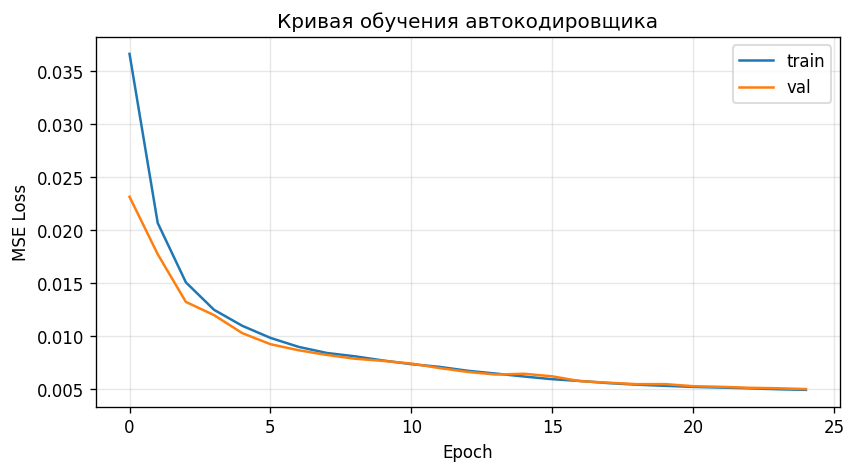

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='train')
ax.plot(val_losses, label='val')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('Кривая обучения автокодировщика')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

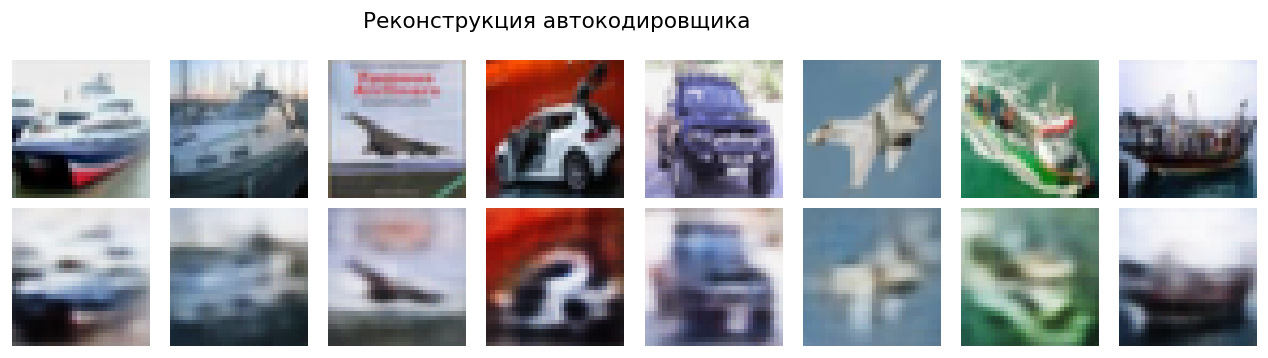

In [8]:
ae.eval()
test_imgs = next(iter(test_loader))[0][:8].to(device)
with torch.no_grad():
    recs = ae(test_imgs)

fig, axes = plt.subplots(2, 8, figsize=(12, 3))
row_labels = ['Оригинал', 'Восстановленное']
for i in range(8):
    axes[0][i].imshow(test_imgs[i].cpu().permute(1, 2, 0).numpy())
    axes[1][i].imshow(recs[i].cpu().permute(1, 2, 0).numpy().clip(0, 1))
for r in range(2):
    for i in range(8):
        axes[r][i].axis('off')
    axes[r][0].set_ylabel(row_labels[r], fontsize=10, rotation=0, ha='right', va='center')
plt.suptitle('Реконструкция автокодировщика', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(left=0.12)
plt.show()

## Генерация. Гауссова модель и SMOTE

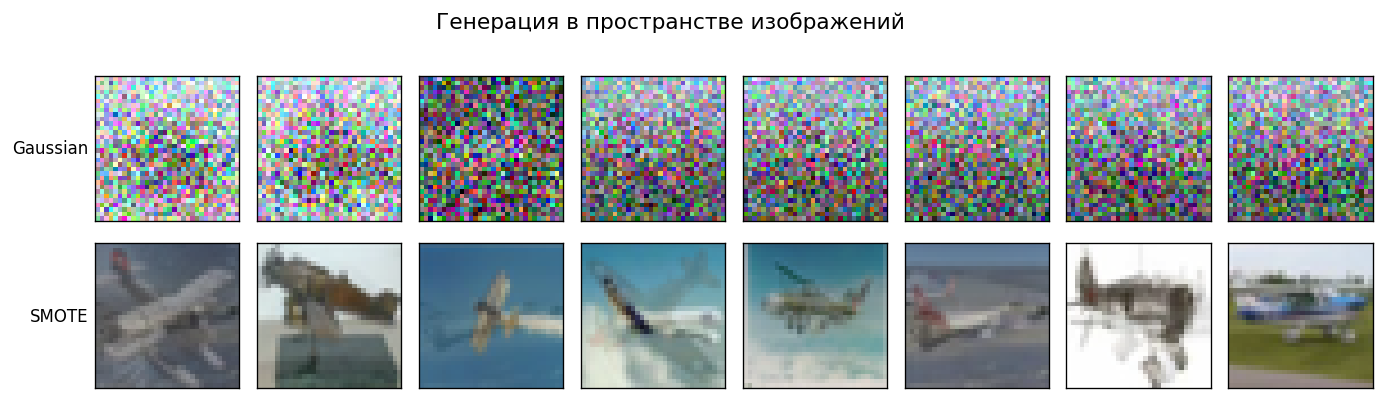

In [ ]:
flat_imgs = all_imgs.view(len(all_imgs), -1).numpy()
flat_labs = all_labs.numpy()

gmm_img = GaussianMixture(n_components=3, covariance_type='diag', random_state=101)
gmm_img.fit(flat_imgs[:3000])
gauss_samples = gmm_img.sample(8)[0].clip(0, 1).reshape(-1, 3, 32, 32)

sub_idx = []
for c in range(3):
    cls_idx = np.where(flat_labs == c)[0]
    n = 150 if c == 0 else 300
    sub_idx.extend(cls_idx[:n])
sub_flat = flat_imgs[sub_idx]
sub_y = flat_labs[sub_idx]

X_sm, y_sm = SMOTE(k_neighbors=5).fit_resample(sub_flat, sub_y)
smote_samples = X_sm[len(sub_flat):].clip(0, 1).reshape(-1, 3, 32, 32)

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i in range(8):
    axes[0][i].imshow(np.transpose(gauss_samples[i], (1, 2, 0)))
    axes[0][i].set_xticks([])
    axes[0][i].set_yticks([])
for i in range(min(8, len(smote_samples))):
    axes[1][i].imshow(np.transpose(smote_samples[i], (1, 2, 0)))
    axes[1][i].set_xticks([])
    axes[1][i].set_yticks([])
axes[0][0].set_ylabel('Gaussian', fontsize=10, rotation=0, ha='right', va='center')
axes[1][0].set_ylabel('SMOTE', fontsize=10, rotation=0, ha='right', va='center')
fig.suptitle('Генерация в пространстве изображений', fontsize=13)
fig.tight_layout()
fig.subplots_adjust(left=0.1)
plt.show()

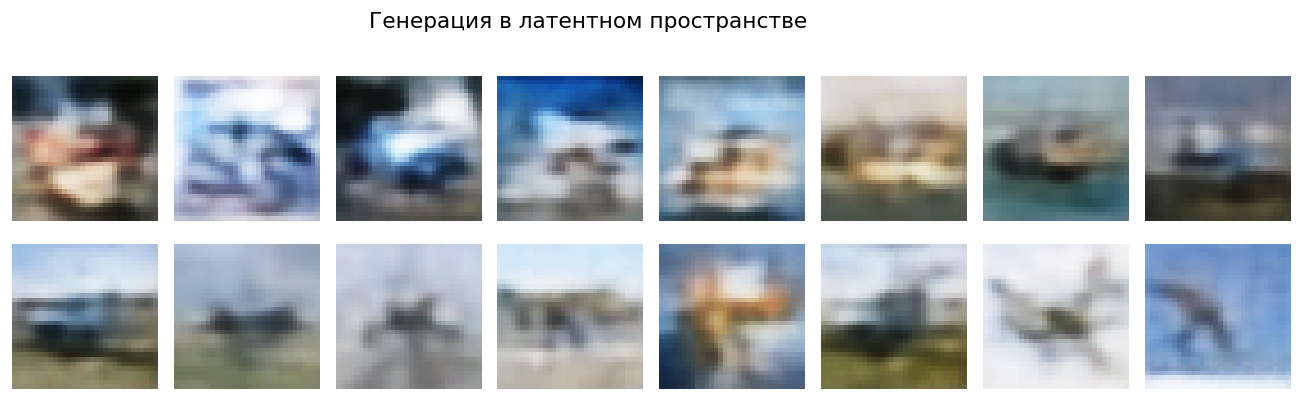

In [ ]:
ae.eval()
latent_list = []
with torch.no_grad():
    for i in range(0, len(all_imgs), 256):
        batch = all_imgs[i:i+256].to(device)
        latent_list.append(ae.encode(batch).cpu())
latent = torch.cat(latent_list).numpy()
lat_labs = all_labs.numpy()

gmm_lat = GaussianMixture(n_components=3, covariance_type='full', random_state=101)
gmm_lat.fit(latent)
lat_gauss = gmm_lat.sample(8)[0].astype(np.float32)

sub_lat, sub_y = [], []
for c in range(3):
    cls_lat = latent[lat_labs == c]
    n = 150 if c == 0 else 300
    sub_lat.append(cls_lat[:n])
    sub_y.extend([c] * min(n, len(cls_lat)))
sub_lat = np.vstack(sub_lat)
sub_y = np.array(sub_y)

lat_sm, _ = SMOTE(k_neighbors=5).fit_resample(sub_lat, sub_y)
lat_sm_new = lat_sm[len(sub_lat):].astype(np.float32)

with torch.no_grad():
    dec_gauss = ae.decode(torch.tensor(lat_gauss).to(device)).cpu()
    dec_smote = ae.decode(torch.tensor(lat_sm_new[:8]).to(device)).cpu()

fig, axes = plt.subplots(2, 8, figsize=(12, 3.5))
for i in range(8):
    axes[0][i].imshow(dec_gauss[i].permute(1, 2, 0).numpy().clip(0, 1))
    axes[0][i].axis('off')
for i in range(8):
    axes[1][i].imshow(dec_smote[i].permute(1, 2, 0).numpy().clip(0, 1))
    axes[1][i].axis('off')
plt.suptitle('Генерация в латентном пространстве', fontsize=13)
plt.tight_layout()
plt.subplots_adjust(left=0.1)
plt.show()

## Диффузионная модель (DDPM)

In [17]:
class SinPosEmb(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2

        log_coeff = math.log(10000) / (half_dim - 1)
        inv_freq = torch.arange(half_dim, device=t.device).float()
        inv_freq = torch.exp(inv_freq * (-log_coeff))

        t_float = t[:, None].float()
        angles = t_float * inv_freq[None]

        sin_part = angles.sin()
        cos_part = angles.cos()
        return torch.cat([sin_part, cos_part], dim=-1)


class ResBlock(nn.Module):
    def __init__(self, ch_in, ch_out, emb_dim):
        super().__init__()
        self.ch_in = ch_in
        self.ch_out = ch_out
        self.norm1 = nn.GroupNorm(8, ch_in)
        self.conv1 = nn.Conv2d(ch_in, ch_out, 3, padding=1)
        self.norm2 = nn.GroupNorm(8, ch_out)
        self.conv2 = nn.Conv2d(ch_out, ch_out, 3, padding=1)
        self.emb_proj = nn.Linear(emb_dim, ch_out)
        if ch_in != ch_out:
            self.skip = nn.Conv2d(ch_in, ch_out, 1)
        self.act = nn.SiLU()

    def forward(self, x, emb):
        h = self.conv1(self.act(self.norm1(x)))
        h = h + self.emb_proj(emb)[:, :, None, None]
        h = self.conv2(self.act(self.norm2(h)))
        if self.ch_in != self.ch_out:
            x = self.skip(x)
        return h + x


class UNet(nn.Module):
    def __init__(self, n_classes=3, emb_dim=128):
        super().__init__()
        self.time_emb = nn.Sequential(
            SinPosEmb(emb_dim),
            nn.Linear(emb_dim, emb_dim),
            nn.SiLU(),
            nn.Linear(emb_dim, emb_dim)
        )
        self.cls_emb = nn.Embedding(n_classes, emb_dim)

        self.init_conv = nn.Conv2d(3, 64, 3, padding=1)
        self.e1 = ResBlock(64, 64, emb_dim)
        self.e2 = ResBlock(64, 128, emb_dim)
        self.e3 = ResBlock(128, 256, emb_dim)
        self.pool = nn.MaxPool2d(2)

        self.bot1 = ResBlock(256, 256, emb_dim)
        self.bot2 = ResBlock(256, 256, emb_dim)

        self.up3 = nn.ConvTranspose2d(256, 256, 2, stride=2)
        self.d3 = ResBlock(512, 128, emb_dim)
        self.up2 = nn.ConvTranspose2d(128, 128, 2, stride=2)
        self.d2 = ResBlock(256, 64, emb_dim)
        self.up1 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.d1 = ResBlock(128, 64, emb_dim)

        self.out = nn.Sequential(nn.GroupNorm(8, 64), nn.SiLU(), nn.Conv2d(64, 3, 1))

    def forward(self, x, t, c=None, c_emb=None):
        emb = self.time_emb(t)
        if c_emb is not None:
            emb = emb + c_emb
        else:
            emb = emb + self.cls_emb(c)

        x = self.init_conv(x)
        x1 = self.e1(x, emb)
        x2 = self.e2(self.pool(x1), emb)
        x3 = self.e3(self.pool(x2), emb)

        h = self.bot2(self.bot1(self.pool(x3), emb), emb)

        h = self.d3(torch.cat([self.up3(h), x3], 1), emb)
        h = self.d2(torch.cat([self.up2(h), x2], 1), emb)
        h = self.d1(torch.cat([self.up1(h), x1], 1), emb)
        return self.out(h)

DDPM:   0%|          | 0/80 [00:00<?, ?it/s]

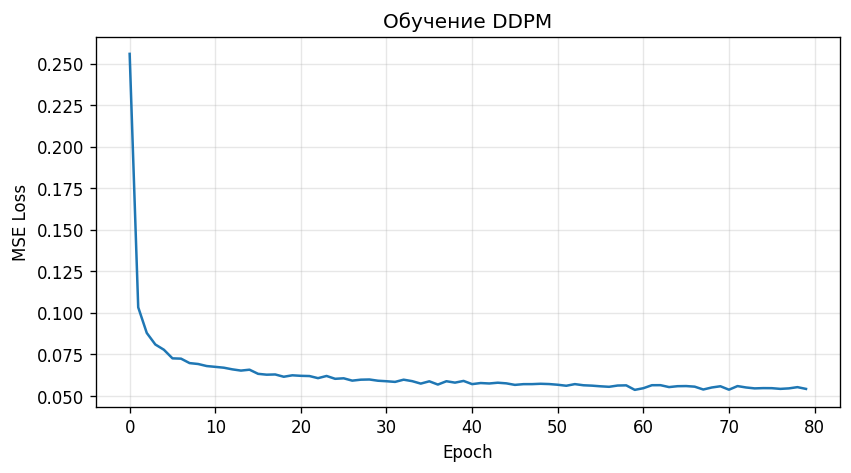

In [18]:
T = 300
betas = torch.linspace(1e-4, 0.02, T).to(device)
alphas = 1 - betas
alpha_bar = torch.cumprod(alphas, 0)

unet = UNet(n_classes=3).to(device)
opt_ddpm = torch.optim.Adam(unet.parameters(), lr=2e-4)
ddpm_losses = []

pbar = trange(80, desc='DDPM')
for epoch in pbar:
    unet.train()
    ep_loss = 0
    n_batches = 0
    for imgs, labs in train_loader:
        imgs = imgs.to(device) * 2 - 1
        labs = labs.to(device)

        t = torch.randint(0, T, (imgs.shape[0],), device=device)
        noise = torch.randn_like(imgs)
        ab = alpha_bar[t].view(-1, 1, 1, 1)
        noisy = ab.sqrt() * imgs + (1 - ab).sqrt() * noise

        pred = unet(noisy, t, c=labs)
        loss = F.mse_loss(pred, noise)
        opt_ddpm.zero_grad()
        loss.backward()
        opt_ddpm.step()

        ep_loss += loss.item()
        n_batches += 1

    ddpm_losses.append(ep_loss / n_batches)
    pbar.set_postfix(loss=f'{ddpm_losses[-1]:.4f}')

plt.figure(figsize=(8, 4))
plt.plot(ddpm_losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Обучение DDPM')
plt.grid(alpha=0.3)
plt.show()

In [19]:
@torch.no_grad()
def sample_ddpm(model, n, cls):
    model.eval()
    x = torch.randn(n, 3, 32, 32, device=device)
    c = torch.full((n,), cls, dtype=torch.long, device=device)

    for i in reversed(range(T)):
        t = torch.full((n,), i, dtype=torch.long, device=device)
        pred = model(x, t, c=c)

        beta_t = betas[i]
        alpha_t = alphas[i]
        ab_t = alpha_bar[i]
        x = (x - beta_t / (1 - ab_t).sqrt() * pred) / alpha_t.sqrt()
        if i > 0:
            x += beta_t.sqrt() * torch.randn_like(x)

    return ((x + 1) / 2).clamp(0, 1)


@torch.no_grad()
def sample_ddpm_interpolate(model, cls_emb):
    model.eval()
    n = cls_emb.shape[0]
    x = torch.randn(n, 3, 32, 32, device=device)

    for i in reversed(range(T)):
        t = torch.full((n,), i, dtype=torch.long, device=device)
        pred = model(x, t, c_emb=cls_emb)

        beta_t = betas[i]
        alpha_t = alphas[i]
        ab_t = alpha_bar[i]
        x = (x - beta_t / (1 - ab_t).sqrt() * pred) / alpha_t.sqrt()
        if i > 0:
            x += beta_t.sqrt() * torch.randn_like(x)

    return ((x + 1) / 2).clamp(0, 1)

## Результаты генерации DDPM

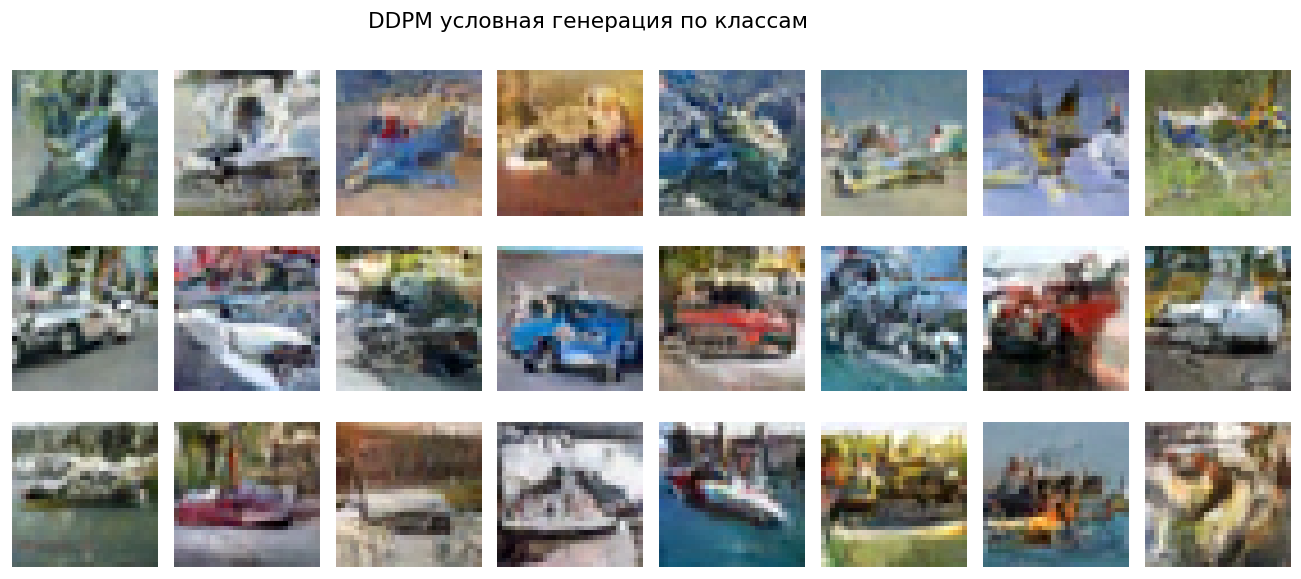

In [25]:
fig, axes = plt.subplots(3, 8, figsize=(12, 5))
for c in range(3):
    generated = sample_ddpm(unet, 8, c)
    for j in range(8):
        ax = axes[c][j]
        ax.imshow(generated[j].cpu().permute(1, 2, 0).numpy())
        ax.axis('off')
fig.suptitle('DDPM условная генерация по классам', fontsize=13)
fig.tight_layout()
fig.subplots_adjust(left=0.1)
plt.show()

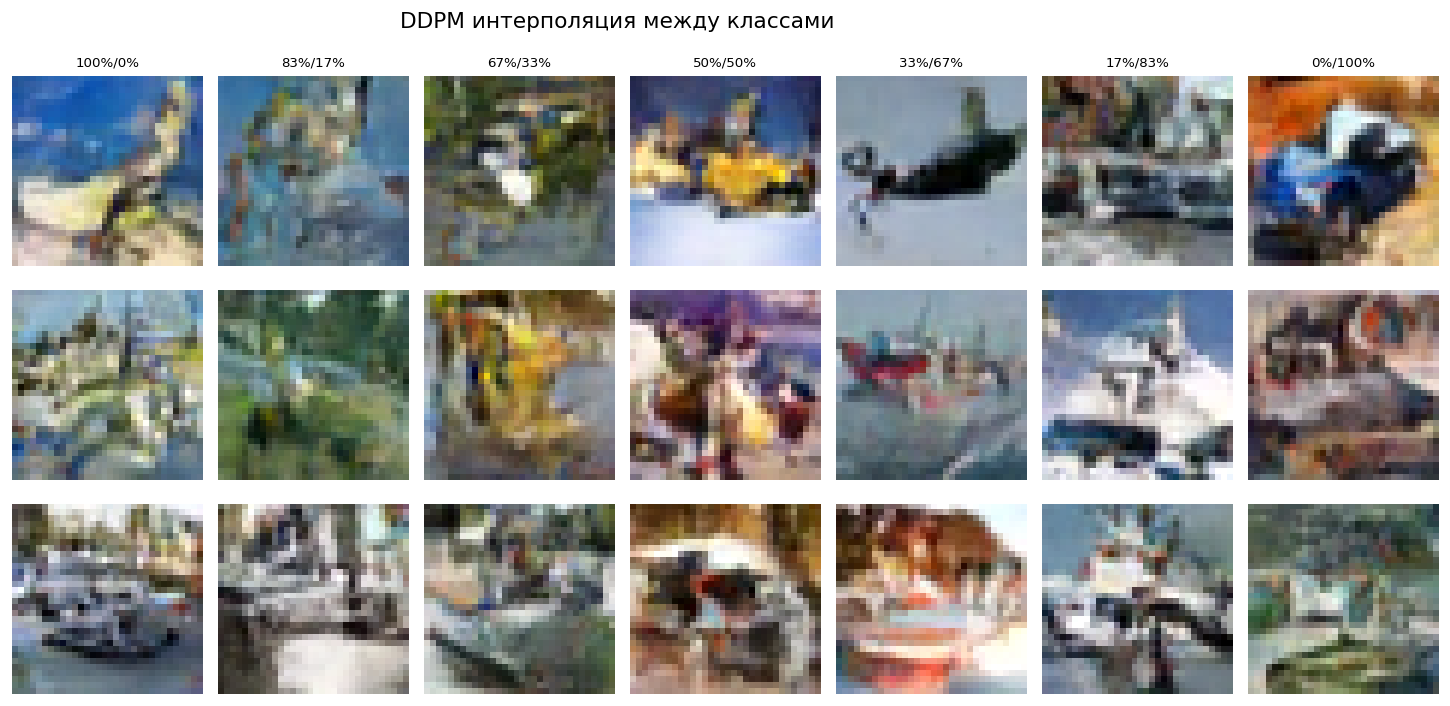

In [23]:
pairs = [(0, 1), (0, 2), (1, 2)]
weights = np.linspace(0, 1, 7).tolist()

fig, axes = plt.subplots(len(pairs), 7, figsize=(14, 6))
for row, (c1, c2) in enumerate(pairs):
    emb1 = unet.cls_emb(torch.tensor([c1], device=device)).squeeze(0)
    emb2 = unet.cls_emb(torch.tensor([c2], device=device)).squeeze(0)
    embs = torch.stack([(1 - w) * emb1 + w * emb2 for w in weights])
    imgs = sample_ddpm_interpolate(unet, embs)
    for col in range(7):
        ax = axes[row][col]
        ax.imshow(imgs[col].cpu().permute(1, 2, 0).numpy())
        ax.axis('off')
        if row == 0:
            ax.set_title(f'{1-weights[col]:.0%}/{weights[col]:.0%}', fontsize=8)

fig.suptitle('DDPM интерполяция между классами', fontsize=13)
fig.tight_layout()
fig.subplots_adjust(left=0.14)
plt.show()